In [129]:
import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import ticker
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import pearsonr
import math


In [130]:
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

hexcolors = [
    "#D1B8D7", "#AE76A3", "#882E72", "#1965B0", "#5289C7",
    "#7BAFDE", "#4EB265", "#90C987", "#CAE0AB", "#F7F056",
    "#F6C141", "#F1932D", "#E8601C", "#DC050C", "#777777",
]
colornames = [
    "purple1", "purple2", "purple3", "blue1", "blue2", "blue3",
    "green1", "green2", "green3", "yellow1", "yellow2", "orange1",
    "orange2", "red", "grey",
]
rnb_colors = dict(zip(colornames, hexcolors))

gradient_colors = [
    rnb_colors["blue2"],
    rnb_colors["green1"],
    rnb_colors["yellow2"],
    rnb_colors["red"],
]
cmap = mpl.colors.LinearSegmentedColormap.from_list("temp_gradient", gradient_colors, N=256)
marker_cycle = ["o", "s", "^", "D"]


In [131]:
def pearsonr_bootstrapped(
    x: np.ndarray,
    y: np.ndarray,
    n_bootstraps: int = 10000,
    random_state: int | None = 42,) -> tuple[float, float]:
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n_samples = len(x)
    if n_samples < 2:
        return np.nan, np.nan
    r_orig = pearsonr(x, y)[0]
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n_samples, size=(n_bootstraps, n_samples), replace=True)
    x_boot, y_boot = x[idx], y[idx]
    dx = x_boot - np.mean(x_boot, axis=1, keepdims=True)
    dy = y_boot - np.mean(y_boot, axis=1, keepdims=True)
    cov = np.sum(dx * dy, axis=1)
    var_x = np.sum(dx**2, axis=1)
    var_y = np.sum(dy**2, axis=1)
    denom = np.sqrt(var_x * var_y)
    valid = denom > 0
    r_boot = np.full(n_bootstraps, np.nan)
    r_boot[valid] = cov[valid] / denom[valid]
    return float(r_orig), float(np.nanstd(r_boot, ddof=1))

## Data for figure 2

In [ ]:
#Simulation data
sim_files = [
    {"lipid": "DOPC", "T": 293.15, "file": "data/lipid_scan/DOPC_100_T_293.15_bilayer_prop.csv"},
    {"lipid": "DOPC", "T": 303.15, "file": "data/lipid_scan/DOPC_100_T_303.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 293.15, "file": "data/lipid_scan/POPC_100_T_293.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 303.15, "file": "data/lipid_scan/POPC_100_T_303.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 323.15, "file": "data/lipid_scan/POPC_100_T_323.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 333.15, "file": "data/lipid_scan/POPC_100_T_333.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 298.15, "file": "data/lipid_scan/POPS_100_T_298.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 308.15, "file": "data/lipid_scan/POPS_100_T_308.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 318.15, "file": "data/lipid_scan/POPS_100_T_318.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 328.15, "file": "data/lipid_scan/POPS_100_T_328.15_bilayer_prop.csv"}
]

sim_data = []
for item in sim_files:
    data = pd.read_csv(item["file"], index_col=0)
    sim_data.append({
        "lipid": item["lipid"],
        "temp_K": item["T"],
        "calv_apl_A^2": data.loc["apl", "value"] * 100,
        "calv_apl_err_A^2": data.loc["apl", "error"] * 100,
        "calv_dpp_nm": data.loc["dpp", "value"],
        "calv_dpp_err_nm": data.loc["dpp", "error"],
    })
sim = pd.DataFrame(sim_data)
sim.set_index(["lipid", "temp_K"], inplace=True)

#Reference data
apl_ref = pd.read_csv("data/lipid_scan/figure1_apl_data.csv", skiprows=1) # from https://github.com/Martini-Force-Field-Initiative/M3-Lipid-Parameters/blob/main/Martini_lipid_Benchmark/figure1_apl_data.csv
dpp_ref = pd.read_csv("data/lipid_scan/figure1_db_data.csv", skiprows=1) # from https://github.com/Martini-Force-Field-Initiative/M3-Lipid-Parameters/blob/main/Martini_lipid_Benchmark/figure1_db_data.csv
pan_ref = pd.read_csv("data/lipid_scan/pan_et_al_reference.csv") # extracted from https://doi.org/10.1039/c4sm00066h

apl_ref = apl_ref[
    ((apl_ref["lipid"] == "DOPC") & (apl_ref["temp_K"].isin([293.15, 303.15]))) |
    ((apl_ref["lipid"] == "POPC") & (apl_ref["temp_K"].isin([293.15, 303.15, 323.15, 333.15])))
]

dpp_ref = dpp_ref[
    ((dpp_ref["lipid"] == "DOPC") & (dpp_ref["temp_K"].isin([293.15, 303.15]))) |
    ((dpp_ref["lipid"] == "POPC") & (dpp_ref["temp_K"].isin([293.15, 303.15, 323.15, 333.15])))
]

pan_ref = pan_ref[
    (pan_ref["lipid"] == "POPS") &
    (pan_ref["temp_K"].isin([298.15, 308.15, 318.15, 328.15]))
]

ref_pc = pd.merge(apl_ref, dpp_ref, on=["lipid", "temp_K"], how="outer")
ref = pd.concat([ref_pc, pan_ref], ignore_index=True)

# Convert APL from nm² to Å²
apl_cols = [
    "exp_apl_nm^2",
    "exp_apl_err_nm^2",
    "sim_apl_nm^2",
    "sim_apl_err_nm^2"
]
ref[apl_cols] = ref[apl_cols].apply(pd.to_numeric, errors="coerce") * 100

ref.rename(columns={
    "exp_apl_nm^2": "exp_apl_A^2",
    "exp_apl_err_nm^2": "exp_apl_err_A^2",
    "sim_apl_nm^2": "sim_apl_A^2",
    "sim_apl_err_nm^2": "sim_apl_err_A^2"
}, inplace=True)

ref.set_index(["lipid", "temp_K"], inplace=True)




In [133]:
sim

calv_apl_A^2  calv_apl_err_A^2  calv_dpp_nm  calv_dpp_err_nm
lipid temp_K                                                              
DOPC  293.15     65.774430          0.177722      3.95350         0.009271
      303.15     67.165740          0.098634      3.90700         0.009928
POPC  293.15     63.631020          0.097892      4.01625         0.008411
      303.15     64.525280          0.120319      4.00725         0.008204
      323.15     67.818373          0.171703      3.91775         0.010070
      333.15     69.489640          0.138184      3.87925         0.009343
POPS  298.15     64.879750          0.147393      3.96075         0.009189
      308.15     66.234990          0.121176      3.93350         0.008433
      318.15     68.465820          0.083646      3.87950         0.009116
      328.15     70.040050          0.177312      3.84925         0.010068

In [134]:
ref

exp_apl_A^2  exp_apl_err_A^2  sim_apl_A^2  sim_apl_err_A^2  \
lipid temp_K                                                               
DOPC  293.15         64.3              1.3        63.56             0.43   
      303.15         66.9              1.0        65.26             0.45   
POPC  293.15         62.7              1.3        57.78             0.58   
      303.15         64.3              1.3        59.99             0.57   
      323.15         67.3              1.3        63.76             0.41   
      333.15         68.1              1.4        65.41             0.48   
POPS  298.15         62.7              NaN          NaN              NaN   
      308.15         63.9              NaN          NaN              NaN   
      318.15         65.5              NaN          NaN              NaN   
      328.15         67.4              NaN          NaN              NaN   

              exp_db_nm  exp_db_err_nm  sim_db_nm  sim_db_err_nm  \
lipid temp_K                                                       
DOPC  293.15       3.94           0.08     3.9193         0.0225   
      303.15       3.89           0.08     3.8435         0.0245   
POPC  293.15       3.98           0.08     4.1063         0.0328   
      303.15       3.91           0.08     3.9954         0.0475   
      323.15       3.79           0.08     3.8223         0.0265   
      333.15       3.77           0.08     3.7537         0.0374   
POPS  298.15        NaN            NaN        NaN            NaN   
      308.15        NaN            NaN        NaN            NaN   
      318.15        NaN            NaN        NaN            NaN   
      328.15        NaN            NaN        NaN            NaN   

                                          Source  
lipid temp_K                                      
DOPC  293.15                                 NaN  
      303.15                                 NaN  
POPC  293.15                                 NaN  
      303.15                                 NaN  
      323.15                                 NaN  
      333.15                                 NaN  
POPS  298.15  https://doi.org/10.1039/c4sm00066h  
      308.15  https://doi.org/10.1039/c4sm00066h  
      318.15  https://doi.org/10.1039/c4sm00066h  
      328.15  https://doi.org/10.1039/c4sm00066h

In [135]:
# Uniform axis limits, T color code and lipid markers
all_apl = pd.concat([ref["exp_apl_A^2"], ref["sim_apl_A^2"], sim["calv_apl_A^2"]]).dropna()
apl_lims = (all_apl.min() - 2.0, all_apl.max() + 2.0)
temperatures = ref.index.get_level_values("temp_K").unique()
norm = plt.Normalize(temperatures.min(), temperatures.max())

all_lipids = sorted(ref.index.get_level_values("lipid").unique())
marker_map = {
    lip: marker_cycle[i % len(marker_cycle)]
    for i, lip in enumerate(all_lipids)
}


## Figure 2A

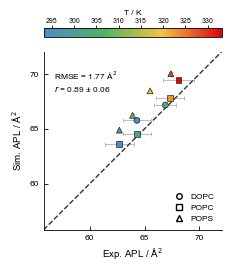

In [136]:
apl_t_df = pd.merge(ref.reset_index(), sim.reset_index(), on=["lipid", "temp_K"], how="outer")

apl_t_df["exp_apl_err_A^2"] = pd.to_numeric(apl_t_df["exp_apl_err_A^2"], errors="coerce").fillna(0)
apl_t_df["calv_apl_err_A^2"] = pd.to_numeric(apl_t_df["calv_apl_err_A^2"], errors="coerce").fillna(0)

#all_apl = pd.concat([apl_t_df["exp_apl_A^2"], apl_t_df["calv_apl_A^2"]]).dropna()
#apl_lims = (all_apl.min() - 7.0, all_apl.max() + 2.0)

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

for lipid, sub in apl_t_df.groupby("lipid"):
    ax.scatter(
        sub["exp_apl_A^2"],
        sub["calv_apl_A^2"],
        c=sub["temp_K"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[lipid],
        edgecolors="k",
        linewidth=0.4,
        s=18,
        zorder=10,
    )

ax.errorbar(
    apl_t_df["exp_apl_A^2"],
    apl_t_df["calv_apl_A^2"],
    xerr=apl_t_df["exp_apl_err_A^2"],
    yerr=apl_t_df["calv_apl_err_A^2"],
    fmt="none",
    ecolor="0.35",
    elinewidth=0.5,
    capsize=1.5,
    capthick=0.5,
    alpha=0.55,
    zorder=2,
)


ax.plot(apl_lims, apl_lims, "--", color="0.2", lw=1.0, zorder=1)

ax.set_xlim(apl_lims)
ax.set_ylim(apl_lims)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel("Exp. APL / Å$^2$")
ax.set_ylabel("Sim. APL / Å$^2$")

x_vals = apl_t_df["exp_apl_A^2"].values
y_vals = apl_t_df["calv_apl_A^2"].values
rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(f"RMSE = {rmsd:.2f} Å$^2$\n$r$ = {r_orig:.2f} ± {r_err:.2f}", (0.06, 0.90), xycoords="axes fraction", fontsize=6, ha="left", va="top", bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0))

lipids_here = sorted(apl_t_df["lipid"].unique())
handles = [
    mlines.Line2D([], [], color="k", marker=marker_map[l], linestyle="None", markersize=4, markerfacecolor="white", label=l)
    for l in lipids_here
]
ax.legend(handles=handles, loc="lower right", frameon=False, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=5, length=2, pad=1)
cb.set_label("T / K", fontsize=6, labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")


plt.show()

## Figure 2B

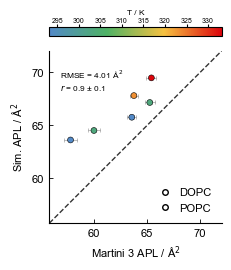

In [146]:
apl_t_martini = pd.merge(ref.reset_index(), sim.reset_index(), on=["lipid", "temp_K"], how="outer")
apl_t_martini = apl_t_martini.dropna(subset=["sim_apl_A^2", "calv_apl_A^2"])

apl_t_martini["sim_apl_err_A^2"] = pd.to_numeric(apl_t_martini["sim_apl_err_A^2"], errors="coerce").fillna(0)
apl_t_martini["calv_apl_err_A^2"] = pd.to_numeric(apl_t_martini["calv_apl_err_A^2"], errors="coerce").fillna(0)

#all_apl = pd.concat([apl_t_martini["sim_apl_A^2"], apl_t_martini["calv_apl_A^2"]]).dropna()
#apl_lims = (all_apl.min() - 7.0, all_apl.max() + 2.0)

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

ax.errorbar(
    apl_t_martini["sim_apl_A^2"],
    apl_t_martini["calv_apl_A^2"],
    xerr=apl_t_martini["sim_apl_err_A^2"],
    yerr=apl_t_martini["calv_apl_err_A^2"],
    fmt="none",
    ecolor="0.35",
    elinewidth=0.5,
    capsize=1.5,
    capthick=0.5,
    alpha=0.55,
    zorder=2,
)

for lipid, sub in apl_t_martini.groupby("lipid"):
    ax.scatter(
        sub["sim_apl_A^2"],
        sub["calv_apl_A^2"],
        c=sub["temp_K"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[lipid],
        edgecolors="k",
        linewidth=0.4,
        s=18,
        zorder=10,
    )

ax.plot(apl_lims, apl_lims, "--", color="0.2", lw=1.0, zorder=1)
ax.set_xlim(apl_lims)
ax.set_ylim(apl_lims)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(direction="in", length=3, width=0.6)

ax.set_xlabel("Martini 3 APL / Å$^2$")
ax.set_ylabel("Sim. APL / Å$^2$")

x_vals = apl_t_martini["sim_apl_A^2"].values
y_vals = apl_t_martini["calv_apl_A^2"].values
rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(f"RMSE = {rmsd:.2f} Å$^2$\n$r$ = {r_orig:.1f} ± {r_err:.1f}", (0.06, 0.90), xycoords="axes fraction", fontsize=6, ha="left", va="top", bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0))

lipids_here = sorted(apl_t_martini["lipid"].unique())
handles = [
    mlines.Line2D([], [], color="k", marker=marker_map[l], linestyle="None", markersize=4, markerfacecolor="white", label=l)
    for l in lipids_here
]
ax.legend(handles=handles, loc="lower right", frameon=False, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=5, length=2, pad=1)
cb.set_label("T / K", fontsize=6, labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")
plt.savefig("martini3_corr.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Figure 2C

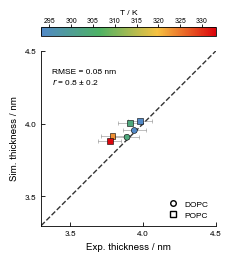

In [138]:
dpp_t_df = pd.merge(ref.reset_index(), sim.reset_index(), on=["lipid", "temp_K"], how="outer")
dpp_t_df = dpp_t_df.dropna(subset=["exp_db_nm", "calv_dpp_nm"])

dpp_t_df["exp_db_err_nm"] = pd.to_numeric(dpp_t_df["exp_db_err_nm"], errors="coerce").fillna(0)
dpp_t_df["calv_dpp_err_nm"] = pd.to_numeric(dpp_t_df["calv_dpp_err_nm"], errors="coerce").fillna(0)


fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

ax.errorbar(
    dpp_t_df["exp_db_nm"],
    dpp_t_df["calv_dpp_nm"],
    xerr=dpp_t_df["exp_db_err_nm"],
    yerr=dpp_t_df["calv_dpp_err_nm"],
    fmt="none",
    ecolor="0.35",
    elinewidth=0.5,
    capsize=1.5,
    capthick=0.5,
    alpha=0.55,
    zorder=2,
)

for lipid, sub in dpp_t_df.groupby("lipid"):
    ax.scatter(
        sub["exp_db_nm"],
        sub["calv_dpp_nm"],
        c=sub["temp_K"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[lipid],
        edgecolors="k",
        linewidth=0.4,
        s=18,
        zorder=10,
    )

ax.plot([3.3, 4.5], [3.3, 4.5], "--", color="0.2", lw=1.0, zorder=1)

ax.set_xlim(3.3, 4.5)
ax.set_ylim(3.3, 4.5)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.tick_params(direction="in", length=3, width=0.6)

ax.set_xlabel("Exp. thickness / nm")
ax.set_ylabel("Sim. thickness / nm")

x_vals = dpp_t_df["exp_db_nm"].values
y_vals = dpp_t_df["calv_dpp_nm"].values
rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(
    f"RMSE = {rmsd:.2f} nm\n$r$ = {r_orig:.1f} ± {r_err:.1f}",
    (0.06, 0.90),
    xycoords="axes fraction",
    fontsize=6,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0),
)

lipids_here = sorted(dpp_t_df["lipid"].unique())
handles = [
    mlines.Line2D([], [], color="k", marker=marker_map[l], linestyle="None", markersize=4, markerfacecolor="white", label=l)
    for l in lipids_here
]
ax.legend(handles=handles, loc="lower right", frameon=False, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=5, length=2, pad=1)
cb.set_label("T / K", fontsize=6, labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")


plt.show()

## Figure 2D

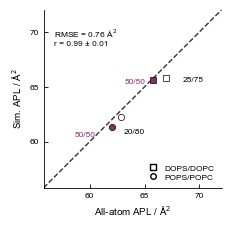

In [139]:
ref_aa_apl = pd.read_csv("data/lipid_scan/mixed_reference.csv")

ref_aa_apl["pair"] = ref_aa_apl["lipid"].astype(str)
ref_aa_apl["ratio"] = ref_aa_apl["ratio"].astype(str).str.split("_").str[0].astype(int)
ref_aa_apl["apl_ref"] = ref_aa_apl["sim_apl_A^2"] 

sim_calv_apl = {
    'POPS_20_POPC_80': 'data/lipid_scan/POPS_20_POPC_80_sigma_0.65_l_0.437_bilayer_prop.csv',
    'POPS_50_POPC_50': 'data/lipid_scan/POPS_50_POPC_50_sigma_0.65_l_0.437_bilayer_prop.csv',
    'DOPS_25_DOPC_75': 'data/lipid_scan/DOPS_25_DOPC_75_sigma_0.65_l_0.437_bilayer_prop.csv',
    'DOPS_50_DOPC_50': 'data/lipid_scan/DOPS_50_DOPC_50_sigma_0.65_l_0.437_bilayer_prop.csv'
}

dfs = []
for label, path in sim_calv_apl.items():
    df = pd.read_csv(path, index_col=0)
    parts = label.split('_')
    
    pair = f"{parts[0]}_{parts[2]}" 
    ratio = int(parts[1])
    
    dfs.append({
        'pair': pair,
        'ratio': ratio,
        'apl': df.loc['apl', 'value'] * 100.0,      # Scale sim to Å^2
        'apl_err': df.loc['apl', 'error'] * 100.0   # Scale sim error to Å^2
    })

df_sim = pd.DataFrame(dfs)

pdf_d = pd.merge(df_sim, ref_aa_apl[["pair", "ratio", "apl_ref"]], on=["pair", "ratio"], how="inner")

x_vals = pdf_d["apl_ref"].values
y_vals = pdf_d["apl"].values
y_errs = pdf_d["apl_err"].fillna(0).values
pairs = pdf_d["pair"].values
ratios = pdf_d["ratio"].values

#all_vals = np.concatenate([x_vals, y_vals])
#apl_lims = (all_vals.min() - 3.0, all_vals.max() + 3.0)

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

marker_map_d = {"DOPS_DOPC": "s", "POPS_POPC": "o"}
fill_col = rnb_colors["purple3"]

for xi, yi, yei, p, r in zip(x_vals, y_vals, y_errs, pairs, ratios):
    mk = marker_map_d.get(p, "o")
    filled = int(r) in [40, 50]
    mfc = fill_col if filled else "white"

    ax.errorbar(
        xi, yi, yerr=yei, fmt=mk, ms=4.5, mfc=mfc, mec="k", mew=0.5,
        ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, zorder=3
    )

ax.plot(apl_lims, apl_lims, "--", color="0.2", lw=1.0, zorder=1)

ax.set_xlim(apl_lims)
ax.set_ylim(apl_lims)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(direction="in", length=3, width=0.6)

ax.set_xlabel("All-atom APL / Å$^2$")
ax.set_ylabel("Sim. APL / Å$^2$")

rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))
r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(
    f"RMSE = {rmsd:.2f} Å$^2$\nr = {r_orig:.2f} ± {r_err:.2f}",
    (0.06, 0.90),
    xycoords="axes fraction",
    fontsize=6,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0),
)

handles_all = [
    mlines.Line2D([], [], color="k", marker="s", linestyle="None", markerfacecolor="white", markersize=4, label="DOPS/DOPC"),
    mlines.Line2D([], [], color="k", marker="o", linestyle="None", markerfacecolor="white", markersize=4, label="POPS/POPC"),
]

ax.legend(
    handles=handles_all,
    loc="lower right",
    frameon=False,
    handletextpad=0.3,
    labelspacing=0.25,
)

ax.annotate("50/50", xy=(0.57, 0.58), xycoords="axes fraction", fontsize=6, ha="right", va="bottom", color=fill_col)
ax.annotate("50/50", xy=(0.29, 0.28), xycoords="axes fraction", fontsize=6, ha="right", va="bottom", color=fill_col)
ax.annotate("20/80", xy=(0.57, 0.3), xycoords="axes fraction", fontsize=6, ha="right", va="bottom", color="k")
ax.annotate("25/75", xy=(0.9, 0.59), xycoords="axes fraction", fontsize=6, ha="right", va="bottom", color="k")

plt.show()

## Figure S1

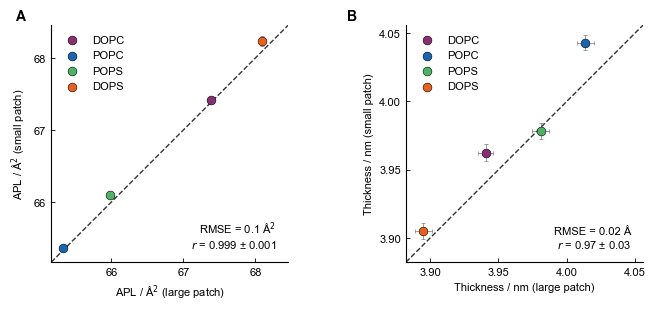

In [ ]:
plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'font.family': 'sans-serif',
})


rows = []
for patch in ['big', 'small']:
    for lipid in ['DOPC', 'POPC', 'DOPS', 'POPS']:
        df = pd.read_csv(f'data/lipid_scan/fse/{patch}/{lipid}_bilayer_prop.csv', index_col=0)
        sysname = f'{lipid}_{patch}'
        rows.append({
            'sysname': sysname,
            'apl': df.loc['apl', 'value'],
            'apl_err': df.loc['apl', 'error'],
            'dpp': df.loc['dpp', 'value'],
            'dpp_err': df.loc['dpp', 'error'],
        })
fse = pd.DataFrame(rows).set_index('sysname')

lipids = ['DOPC', 'POPC', 'POPS', 'DOPS']

colors = {
    'DOPC': rnb_colors['purple3'],
    'POPC': rnb_colors['blue1'],
    'POPS': rnb_colors['green1'],
    'DOPS': rnb_colors['orange2']
}

marker_map = {
    'DOPC': 'o',
    'POPC': 'o',
    'POPS': 'o',
    'DOPS': 'o',
}

fig, ax = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

for lipid in lipids:
    big = fse.loc[f'{lipid}_big']
    small = fse.loc[f'{lipid}_small']

    for a, key, scale in zip(ax, ['apl', 'dpp'], [100, 1]):
        # Convert scalar values safely
        x = float(big[key]) * scale
        y = float(small[key]) * scale
        xe = float(big[f'{key}_err']) * scale
        ye = float(small[f'{key}_err']) * scale

        a.errorbar(x, y, xerr=xe, yerr=ye, fmt='none', ecolor='0.35', elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.8, zorder=2)
        a.scatter(x, y, marker='o', facecolor=colors[lipid], edgecolors='k', linewidth=0.4, s=40, label=lipid, zorder=10)

for a, label in zip(ax, ['APL / Å$^2$', 'Thickness / nm']):
    a.set_xlabel(f'{label} (large patch)')
    a.set_ylabel(f'{label} (small patch)')
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(direction='in', length=3, width=0.6)

    lims = [min(a.get_xlim()[0], a.get_ylim()[0]), max(a.get_xlim()[1], a.get_ylim()[1])]
    a.plot(lims, lims, '--', color='0.2', lw=1.0, zorder=1)
    a.set_aspect('equal', adjustable='box')
    a.set_xlim(lims)
    a.set_ylim(lims)

ax[0].yaxis.set_major_locator(ticker.MultipleLocator(1))
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
ax[1].yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(0.05))

ax[0].legend(frameon=False, loc='upper left')
ax[1].legend(frameon=False, loc='upper left')

apl_big = np.array([fse.loc[f'{l}_big', 'apl'] for l in lipids]) * 100
apl_small = np.array([fse.loc[f'{l}_small', 'apl'] for l in lipids]) * 100

ax[0].annotate(
    "RMSE = {:.1f} Å$^2$\n$r$ = {:.3f} ± {:.3f}".format(
        np.sqrt(np.mean((apl_big - apl_small)**2)),
        *pearsonr_bootstrapped(apl_big, apl_small)
    ),
    xy=(0.95, 0.05),
    xycoords='axes fraction',
    fontsize=8,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, lw=0),
)

dpp_big = np.array([fse.loc[f'{l}_big', 'dpp'] for l in lipids])
dpp_small = np.array([fse.loc[f'{l}_small', 'dpp'] for l in lipids])

ax[1].annotate(
    "RMSE = {:.2f} Å\n$r$ = {:.2f} ± {:.2f}".format(
        np.sqrt(np.mean((dpp_big - dpp_small)**2)),
        *pearsonr_bootstrapped(dpp_big, dpp_small)
    ),
    xy=(0.95, 0.05),
    xycoords='axes fraction',
    fontsize=8,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, lw=0),
)

ax[0].text(-0.15, 1.02, 'A', transform=ax[0].transAxes, fontweight='bold', fontsize=10)
ax[1].text(-0.25, 1.02, 'B', transform=ax[1].transAxes, fontweight='bold', fontsize=10)

#plt.savefig('figS1.pdf')

plt.show()

## Figure S2

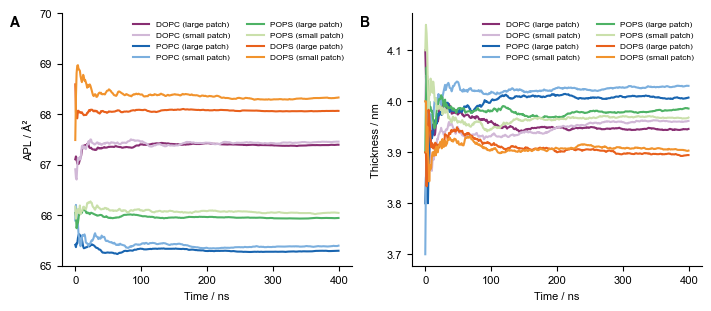

In [ ]:
lipids = ['DOPC', 'POPC', 'POPS', 'DOPS']
patch = ['big', 'small']

patch_dict = {'big': 'large patch', 'small': 'small patch'}

lipid_colors = {
    'DOPC': (rnb_colors['purple3'], rnb_colors['purple1']),  # (big, small)
    'POPC': (rnb_colors['blue1'],   rnb_colors['blue3']),
    'POPS': (rnb_colors['green1'],  rnb_colors['green3']),
    'DOPS': (rnb_colors['orange2'], rnb_colors['orange1'])
}

# Line styles to visually separate big and small
patch_linestyle = {'big': '-', 'small': '-'}

apl_dict = {}
dpp_dict = {}

# Load and calculate cumulative averages
for lipid in lipids:
    for p in patch:
        apl = np.load(
            f'data/lipid_scan/fse/{p}/{lipid}_apl.npy'
        )
        dpp = np.load(
            f'data/lipid_scan/fse/{p}/{lipid}_dpp.npy'
        )

        # Store using a tuple key (lipid, patch)
        key = (lipid, p)
        apl_dict[key] = np.cumsum(apl) / np.arange(1, len(apl) + 1)
        dpp_dict[key] = np.cumsum(dpp) / np.arange(1, len(dpp) + 1)
        

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

for lipid in lipids:
    for idx, p in enumerate(patch):
        key = (lipid, p)
        color = lipid_colors[lipid][idx]  # Pick color variant for patch size
        ls = patch_linestyle[p]
        label = f'{lipid} ({patch_dict[p]})'

        ax[0].plot(
            apl_dict[key] * 100,
            label=label,
            color=color,
            linestyle=ls
        )
    
        ax[1].plot(
            dpp_dict[key],
            label=label,
            color=color,
            linestyle=ls
        )

# Axis formatting
for a, ylabel in zip(ax, ['APL / Å²', 'Thickness / nm']):
    a.set_xlabel('Time / ns')
    a.set_ylabel(ylabel)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

ax[0].set_ylim(65, 70)

# Legend formatting
ax[0].legend(frameon=False, fontsize=6, ncol=2)
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(100))
ax[1].legend(frameon=False, fontsize=6, ncol=2)
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(100))

ax[0].text(
    -0.18, 0.95, 'A',
    transform=ax[0].transAxes,
    fontweight='bold',
    fontsize=10
)

ax[1].text(
    -0.18, 0.95, 'B',
    transform=ax[1].transAxes,
    fontweight='bold',
    fontsize=10
)
#plt.savefig('figS2.pdf')
plt.show()

## Figure S3

In [ ]:
all_lipids = pd.read_excel("data/lipid_scan/autobuild-lipid-properties.xlsx") # from https://github.com/Martini-Force-Field-Initiative/M3-Lipid-Parameters/blob/main/autobuild-lipid-properties.xlsx

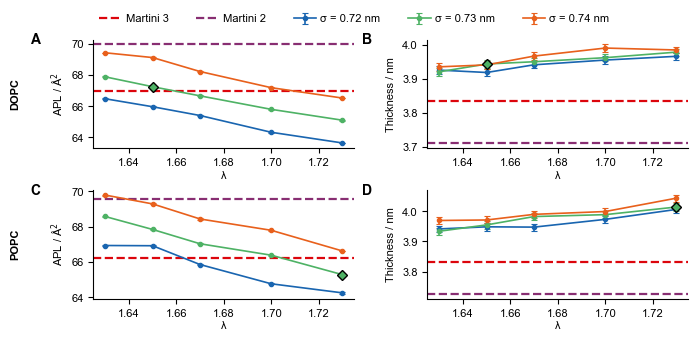

In [143]:
rows_tail = []
lipids = ['DOPC', 'POPC']
for lipid in lipids:
    for l in ['1.63', '1.65', '1.67', '1.7', '1.73']:
        for s in ['0.72', '0.73', '0.74']:
            df = pd.read_csv(
                f'data/lipid_scan/{lipid}_100_sigma_{s}_l_{l}_bilayer_prop.csv', index_col=0)
            rows_tail.append({
                'lipid': lipid, 'l': float(l), 'sigma': float(s),
                'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
                'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
            })

scan_tail = pd.DataFrame(rows_tail)

fig, axs = plt.subplots(2, 2, figsize=(7, 3.5))
fig.subplots_adjust(left=0.13, right=0.98, wspace=0.28, hspace=0.38, top=0.85)

sigma_colors_a = {0.72: rnb_colors['blue1'], 0.73: rnb_colors['green1'], 0.74: rnb_colors['orange2']}
chosen_param = {'DOPC': {'sigma': 0.73, 'l': 1.65}, 'POPC': {'sigma': 0.73, 'l': 1.73}}

for row, lipid in enumerate(['DOPC', 'POPC']):
    target = chosen_param[lipid]
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    
    for sigma, col in sigma_colors_a.items():
        sub = scan_tail[(scan_tail['lipid'] == lipid) & (scan_tail['sigma'] == sigma)].sort_values('l')
        
        panel_apl.errorbar(sub['l'], sub['apl'], yerr=sub['apl_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=f'σ = {sigma} nm', zorder=3)
        panel_dpp.errorbar(sub['l'], sub['dpp'], yerr=sub['dpp_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=f'σ = {sigma} nm', zorder=3)

        if abs(sigma - target['sigma']) < 1e-4:
            pt = sub[sub['l'].between(target['l'] - 1e-4, target['l'] + 1e-4)]
            if not pt.empty:
                panel_apl.plot(pt['l'], pt['apl'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)
                panel_dpp.plot(pt['l'], pt['dpp'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)

    for i, ax in enumerate((panel_apl, panel_dpp)):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.set_xlabel('λ', fontsize=8, labelpad=2)
        ax.grid(False)
        
        letter = chr(ord('A') + row * 2 + i)
        ax.text(-0.24 if i == 0 else -0.25, 1.06, letter, transform=ax.transAxes,
                fontsize=10, weight='bold', va='top', ha='left', clip_on=False)

    panel_apl.set_ylabel('APL / Å$^2$', fontsize=8, labelpad=4)
    panel_dpp.set_ylabel('Thickness / nm', fontsize=8, labelpad=4)
    panel_apl.text(-0.3, 0.5, lipid, transform=panel_apl.transAxes, rotation=90,
                  va='center', ha='center', fontsize=8, weight='bold', clip_on=False)

# Reference Lines
ffs = {
    'M3': {'label': 'Martini 3', 'color': rnb_colors['red']},
    'M2': {'label': 'Martini 2', 'color': rnb_colors['purple3']},
}

for row, lipid in enumerate(lipids):
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    for ref_key, ref_info in ffs.items():
        ref_row = all_lipids[(all_lipids['FF'] == ref_key) & (all_lipids['lipid'] == lipid)]
        apl_val = ref_row['APL PO4 avg/A^2'].values[0]
        dpp_val = ref_row['Thickness PO4 avg/nm'].values[0]
        panel_apl.axhline(apl_val, ls='--', lw=1.6, color=ref_info['color'], label=ref_info['label'])
        panel_dpp.axhline(dpp_val, ls='--', lw=1.6, color=ref_info['color'], label=ref_info['label'])

handles, labels = axs[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

axs[0, 0].legend(frameon=False, loc='lower center', bbox_to_anchor=(1, 1.05),
                 ncol=5, columnspacing=2.5, handletextpad=0.4)

#plt.savefig('figS3.pdf')
plt.show()

## Figure S4

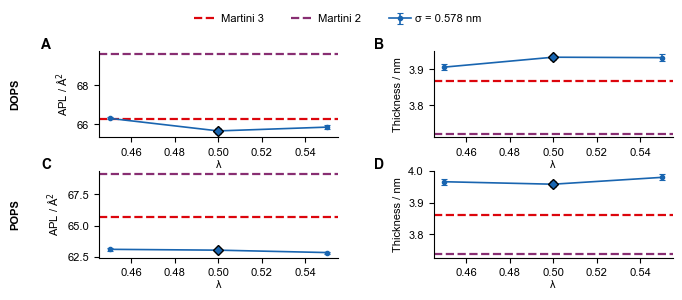

In [ ]:
rows_pho = []
lipids = ['DOPS', 'POPS']
for lipid in lipids:
    for l in ['0.45', '0.5', '0.55']:
        df = pd.read_csv(
            f'data/lipid_scan/{lipid}_100_sigma_0.578_l_{l}_bilayer_prop.csv', index_col=0)
        rows_pho.append({
            'lipid': lipid, 'l': float(l), 'sigma': 0.578,
            'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
            'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
        })

scan_pho = pd.DataFrame(rows_pho)

fig, axs = plt.subplots(2, 2, figsize=(7, 3))
fig.subplots_adjust(left=0.13, right=0.95, wspace=0.4, hspace=0.38, top=0.8)

chosen_param = {'DOPS': {'sigma': 0.578, 'l': 0.5}, 'POPS': {'sigma': 0.578, 'l': 0.5}}

for row, lipid in enumerate(['DOPS', 'POPS']):
    target = chosen_param[lipid]
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    col = rnb_colors['blue1']
    
    sub = scan_pho[scan_pho['lipid'] == lipid].sort_values('l')
    
    panel_apl.errorbar(sub['l'], sub['apl'], yerr=sub['apl_err'], marker='o', ms=3,
                    lw=1.2, capsize=2, capthick=0.8, color=col, label='σ = 0.578 nm', zorder=3)
    panel_dpp.errorbar(sub['l'], sub['dpp'], yerr=sub['dpp_err'], marker='o', ms=3,
                    lw=1.2, capsize=2, capthick=0.8, color=col, label='σ = 0.578 nm', zorder=3)

    pt = sub[sub['l'].between(target['l'] - 1e-4, target['l'] + 1e-4)]
    if not pt.empty:
        panel_apl.plot(pt['l'], pt['apl'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)
        panel_dpp.plot(pt['l'], pt['dpp'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)

    for i, ax in enumerate((panel_apl, panel_dpp)):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.set_xlabel('λ', fontsize=8, labelpad=2)
        ax.grid(False)

        letter = chr(ord('A') + row * 2 + i)
        ax.text(-0.24 if i == 0 else -0.25, 1.15, letter, transform=ax.transAxes,
                fontsize=10, weight='bold', va='top', ha='left', clip_on=False)

    panel_apl.set_ylabel('APL / Å$^2$', fontsize=8, labelpad=4)
    panel_dpp.set_ylabel('Thickness / nm', fontsize=8, labelpad=4)
    panel_apl.text(-0.35, 0.5, lipid, transform=panel_apl.transAxes, rotation=90,
                  va='center', ha='center', fontsize=8, weight='bold', clip_on=False)

# Reference Lines
ffs = {
    'M3': {'label': 'Martini 3', 'color': rnb_colors['red']},
    'M2': {'label': 'Martini 2', 'color': rnb_colors['purple3']},
}

for row, lipid in enumerate(lipids):
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    for ref_key, ref_info in ffs.items():
        ref_row = all_lipids[(all_lipids['FF'] == ref_key) & (all_lipids['lipid'] == lipid)]
        apl_val = ref_row['APL PO4 avg/A^2'].values[0]
        dpp_val = ref_row['Thickness PO4 avg/nm'].values[0]
        panel_apl.axhline(apl_val, ls='--', lw=1.6, color=ref_info['color'], label=ref_info['label'])
        panel_dpp.axhline(dpp_val, ls='--', lw=1.6, color=ref_info['color'], label=ref_info['label'])

handles, labels = axs[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

axs[0, 0].legend(frameon=False, loc='lower center', bbox_to_anchor=(1, 1.19),
                 ncol=3, columnspacing=2.5, handletextpad=0.4)
#plt.savefig('figS4.pdf')
plt.show()

## Figure S5

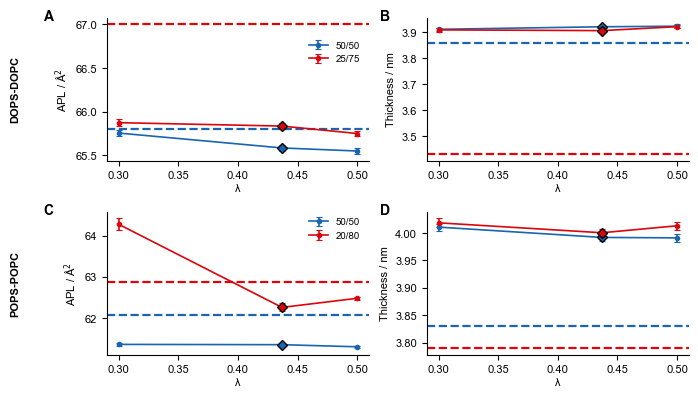

In [ ]:
mix_ref = pd.read_csv('data/lipid_scan/mixed_reference.csv') # extracted from https://doi.org/10.1016/j.bbamem.2024.184376 and https://doi.org/10.1016/j.bbamem.2024.184376

rows_cho = []

# POPS/POPC mixtures
for lipid in ['POPS_50_POPC_50', 'POPS_20_POPC_80']:
    for l in ['0.3', '0.437', '0.5']:
        df = pd.read_csv(
            f'data/lipid_scan/{lipid}_sigma_0.65_l_{l}_bilayer_prop.csv', index_col=0)
        rows_cho.append({
            'lipid': lipid, 'l': float(l), 'sigma': 0.65,
            'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
            'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
        })

# DOPS/DOPC mixtures
for lipid in ['DOPS_50_DOPC_50', 'DOPS_25_DOPC_75']:
    for l in ['0.3', '0.437', '0.5']:
        df = pd.read_csv(
            f'data/lipid_scan/{lipid}_sigma_0.65_l_{l}_bilayer_prop.csv', index_col=0)
        rows_cho.append({
            'lipid': lipid, 'l': float(l), 'sigma': 0.65,
            'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
            'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
        })

scan_cho = pd.DataFrame(rows_cho)

fig, axs = plt.subplots(2, 2, figsize=(7, 4))
fig.subplots_adjust(left=0.08, right=0.95, wspace=0.4, hspace=0.6, top=0.85, bottom=0.1)

mixture_rows = [
    ('DOPS-DOPC', [
        ('DOPS_50_DOPC_50', '50/50', rnb_colors['blue1']), 
        ('DOPS_25_DOPC_75', '25/75', rnb_colors['red'])
    ]),
    ('POPS-POPC', [
        ('POPS_50_POPC_50', '50/50', rnb_colors['blue1']), 
        ('POPS_20_POPC_80', '20/80', rnb_colors['red'])
    ]),
]

for row, (row_label, series) in enumerate(mixture_rows):
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    csv_pair = row_label.replace('-', '_') 
    
    for lipid_key, ratio_label, col in series:
        sub = scan_cho[scan_cho['lipid'] == lipid_key].sort_values('l')
        
        panel_apl.errorbar(sub['l'], sub['apl'], yerr=sub['apl_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=ratio_label, zorder=3)
        panel_dpp.errorbar(sub['l'], sub['dpp'], yerr=sub['dpp_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=ratio_label, zorder=3)

        pt = sub[sub['l'].between(0.437 - 1e-4, 0.437 + 1e-4)]
        if not pt.empty:
            panel_apl.plot(pt['l'], pt['apl'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)
            panel_dpp.plot(pt['l'], pt['dpp'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)

        csv_ratio = ratio_label.replace('/', '_')
        ref_match = mix_ref[(mix_ref['lipid'] == csv_pair) & (mix_ref['ratio'] == csv_ratio)]
        
        
        #APL reference 
        apl_ref_val = ref_match['sim_apl_A^2'].values[0]
        panel_apl.axhline(apl_ref_val, ls='--', lw=1.6, color=col, zorder=1)
            
        #Thickness reference 
        dpp_ref_val = ref_match['sim_dpp_nm'].values[0]
        panel_dpp.axhline(dpp_ref_val, ls='--', lw=1.6, color=col, zorder=1)

    for i, ax in enumerate((panel_apl, panel_dpp)):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.set_xlabel('λ', fontsize=8, labelpad=2)
        ax.grid(False)
        
        letter = chr(ord('A') + row * 2 + i)
        ax.text(-0.24 if i == 0 else -0.18, 1.06, letter, transform=ax.transAxes,
                fontsize=10, weight='bold', va='top', ha='left', clip_on=False)

    panel_apl.set_ylabel('APL / Å$^2$', fontsize=8, labelpad=4)
    panel_dpp.set_ylabel('Thickness / nm', fontsize=8, labelpad=4)
    panel_apl.text(-0.35, 0.5, row_label, transform=panel_apl.transAxes, rotation=90,
                   va='center', ha='center', fontsize=8, weight='bold', clip_on=False)

axs[0, 0].legend(frameon=False, loc='upper right', fontsize=7, ncols=1, bbox_to_anchor=(1, 0.9))
axs[1, 0].legend(frameon=False, loc='upper right', fontsize=7, ncols=1, bbox_to_anchor=(1, 1.02))

plt.tight_layout()
#plt.savefig('figS5.pdf')
plt.show()